In [27]:
# Cell 1: Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

# Mount Drive
drive.mount('/content/drive')

# Paths
BASE_DIR = Path("/content/drive/MyDrive/mbti-tune")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"

print("Setup complete")
print(f"Data directory: {PROCESSED_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete
Data directory: /content/drive/MyDrive/mbti-tune/data/processed


Dataset shape: (4201, 49)
Columns: ['mbti', 'function_pair', 'playlist_name', 'playlist_id', 'track_count', 'danceability_mean', 'danceability_stdev', 'energy_mean', 'energy_stdev', 'loudness_mean']...

Total missing values: 8

Missing values per column:
csharp_dbminor_count    2
dsharp_ebminor_count    4
gsharp_abminor_count    2
dtype: int64

=== MBTI Class Distribution ===
mbti
INTJ    307
ESTP    306
INFJ    304
ENTJ    303
ENTP    303
ENFP    302
ENFJ    302
ISTP    300
INTP    299
ISFP    295
INFP    295
ESFP    231
ISFJ    221
ISTJ    196
ESTJ    122
ESFJ    115
Name: count, dtype: int64


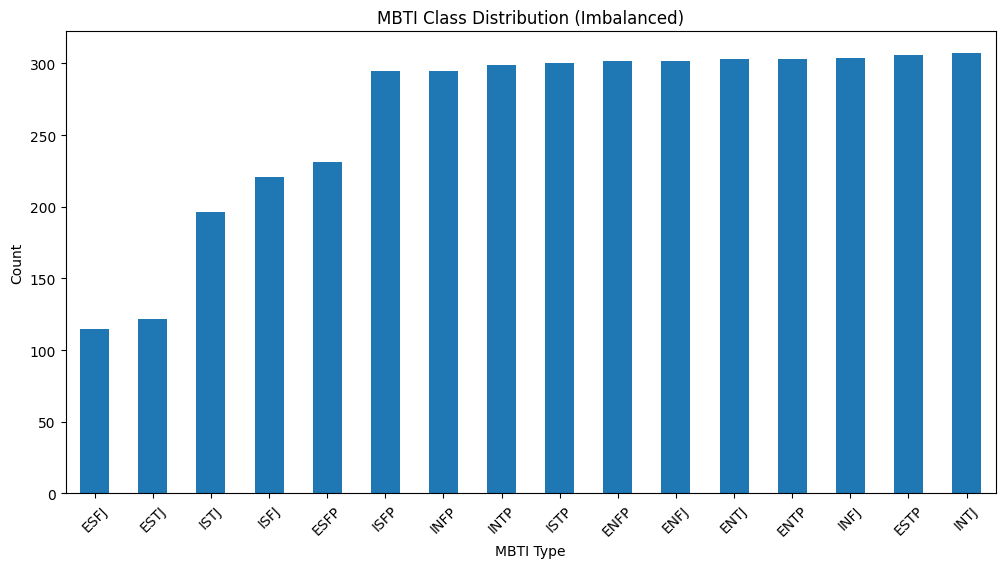

In [28]:
# Cell 2: Load and inspect data
mbti = pd.read_csv(PROCESSED_DIR / "mbti_clean.csv")

print(f"Dataset shape: {mbti.shape}")
print(f"Columns: {mbti.columns.tolist()[:10]}...")

# Check for missing values
print(f"\nTotal missing values: {mbti.isnull().sum().sum()}")
print("\nMissing values per column:")
print(mbti.isnull().sum()[mbti.isnull().sum() > 0])

# Show class distribution
print("\n=== MBTI Class Distribution ===")
class_counts = mbti['mbti'].value_counts()
print(class_counts)

# Visualize imbalance
plt.figure(figsize=(12, 6))
class_counts.sort_values().plot(kind='bar')
plt.title("MBTI Class Distribution (Imbalanced)")
plt.xlabel("MBTI Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [29]:
# Cell 3: Remove rows with missing values
print(f"Original shape: {mbti.shape}")

# Drop rows with any NaN values
mbti_clean = mbti.dropna()
print(f"After dropping NaN: {mbti_clean.shape}")
print(f"Rows removed: {mbti.shape[0] - mbti_clean.shape[0]}")

# Verify no missing values remain
print(f"\nRemaining missing values: {mbti_clean.isnull().sum().sum()}")

# Show new class distribution
print("\n=== MBTI Class Distribution (After Cleaning) ===")
print(mbti_clean['mbti'].value_counts().sort_index())

Original shape: (4201, 49)
After dropping NaN: (4197, 49)
Rows removed: 4

Remaining missing values: 0

=== MBTI Class Distribution (After Cleaning) ===
mbti
ENFJ    302
ENFP    302
ENTJ    303
ENTP    303
ESFJ    115
ESFP    229
ESTJ    122
ESTP    306
INFJ    304
INFP    295
INTJ    307
INTP    299
ISFJ    221
ISFP    295
ISTJ    194
ISTP    300
Name: count, dtype: int64


In [30]:
# Cell 4: Define features and split
# Define the 43 statistical features
STATS_FEATURES = [
    'track_count',
    'danceability_mean', 'danceability_stdev',
    'energy_mean', 'energy_stdev',
    'loudness_mean', 'loudness_stdev',
    'mode_mean', 'mode_stdev',
    'speechiness_mean', 'speechiness_stdev',
    'acousticness_mean', 'acousticness_stdev',
    'liveness_mean', 'liveness_stdev',
    'valence_mean', 'valence_stdev',
    'tempo_mean', 'tempo_stdev',
    'instrumentalness_mean', 'instrumentalness_stdev',
    'cminor_count', 'cmajor_count',
    'csharp_dbminor_count', 'csharp_dbmajor_count',
    'dmajor_count', 'dsharp_ebminor_count', 'dsharp_ebmajor_count',
    'emajor_count', 'fminor_count', 'fmajor_count',
    'fsharp_gbminor_count', 'fsharp_gbmajor_count',
    'gminor_count', 'gmajor_count',
    'gsharp_abminor_count', 'gsharp_abmajor_count',
    'amajor_count', 'asharp_bbminor_count', 'asharp_bbmajor_count',
    'bminor_count', 'bmajor_count', 'dminor_count', 'eminor_count', 'aminor_count'
]

# Filter to only existing columns
existing_features = [f for f in STATS_FEATURES if f in mbti_clean.columns]
print(f"Found {len(existing_features)} features")

X = mbti_clean[existing_features].values
y = mbti_clean['mbti'].values

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Found 45 features
Features shape: (4197, 45)
Labels shape: (4197,)


In [31]:
# Cell 5: Train-test split
from sklearn.model_selection import train_test_split

# Split first (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# Check distribution in train set
print("\n=== Train Set Distribution ===")
train_counts = pd.Series(y_train).value_counts().sort_index()
print(train_counts)

# Check test set distribution
print("\n=== Test Set Distribution ===")
test_counts = pd.Series(y_test).value_counts().sort_index()
print(test_counts)

Train size: 2937
Test size: 1260

=== Train Set Distribution ===
ENFJ    211
ENFP    211
ENTJ    212
ENTP    212
ESFJ     81
ESFP    160
ESTJ     85
ESTP    214
INFJ    213
INFP    206
INTJ    215
INTP    209
ISFJ    155
ISFP    207
ISTJ    136
ISTP    210
Name: count, dtype: int64

=== Test Set Distribution ===
ENFJ    91
ENFP    91
ENTJ    91
ENTP    91
ESFJ    34
ESFP    69
ESTJ    37
ESTP    92
INFJ    91
INFP    89
INTJ    92
INTP    90
ISFJ    66
ISFP    88
ISTJ    58
ISTP    90
Name: count, dtype: int64


In [32]:
# Cell 6: Apply SMOTE to balance training data
from imblearn.over_sampling import SMOTE

print("Applying SMOTE to balance training data...")
print(f"Before SMOTE: {len(X_train)} samples")

# Apply SMOTE with k_neighbors=1 for small classes
# Using k_neighbors=1 prevents NaN issues with very small classes
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"After SMOTE: {len(X_train_balanced)} samples")

# Check balanced distribution
print("\n=== Balanced Train Set Distribution ===")
balanced_counts = pd.Series(y_train_balanced).value_counts().sort_index()
print(balanced_counts)

# Verify no NaNs after SMOTE
print(f"\nNaN in features after SMOTE: {np.isnan(X_train_balanced).sum()}")
print(f"NaN in labels after SMOTE: {pd.Series(y_train_balanced).isnull().sum()}")

Applying SMOTE to balance training data...
Before SMOTE: 2937 samples
After SMOTE: 3440 samples

=== Balanced Train Set Distribution ===
ENFJ    215
ENFP    215
ENTJ    215
ENTP    215
ESFJ    215
ESFP    215
ESTJ    215
ESTP    215
INFJ    215
INFP    215
INTJ    215
INTP    215
ISFJ    215
ISFP    215
ISTJ    215
ISTP    215
Name: count, dtype: int64

NaN in features after SMOTE: 0
NaN in labels after SMOTE: 0


In [33]:
# Cell 7: Scale features (fit on balanced train, transform test)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled train shape: {X_train_scaled.shape}")
print(f"Scaled test shape: {X_test_scaled.shape}")
print(f"\nTrain mean: {X_train_scaled.mean():.6f}")
print(f"Train std: {X_train_scaled.std():.6f}")
print(f"Test mean: {X_test_scaled.mean():.6f}")
print(f"Test std: {X_test_scaled.std():.6f}")

# Save scaler for later use
import joblib
joblib.dump(scaler, PROCESSED_DIR / "mbti_scaler.pkl")
print(f"\nScaler saved to: {PROCESSED_DIR / 'mbti_scaler.pkl'}")

Scaled train shape: (3440, 45)
Scaled test shape: (1260, 45)

Train mean: 0.000000
Train std: 1.000000
Test mean: 0.019084
Test std: 1.011307

Scaler saved to: /content/drive/MyDrive/mbti-tune/data/processed/mbti_scaler.pkl


In [34]:
# Cell 8: Convert to PyTorch tensors
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Get unique types
unique_types = np.array(sorted(mbti_clean['mbti'].unique()))
print(f"Classes: {unique_types}")

# Create label mapping
label_to_idx = {label: idx for idx, label in enumerate(unique_types)}

# Convert labels to indices
y_train_idx = np.array([label_to_idx[label] for label in y_train_balanced])
y_test_idx = np.array([label_to_idx[label] for label in y_test])

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_idx, dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_idx, dtype=torch.long)

print(f"Train tensor shapes: {X_train_t.shape}, {y_train_t.shape}")
print(f"Test tensor shapes: {X_test_t.shape}, {y_test_t.shape}")

# Create DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Classes: ['ENFJ' 'ENFP' 'ENTJ' 'ENTP' 'ESFJ' 'ESFP' 'ESTJ' 'ESTP' 'INFJ' 'INFP'
 'INTJ' 'INTP' 'ISFJ' 'ISFP' 'ISTJ' 'ISTP']
Train tensor shapes: torch.Size([3440, 45]), torch.Size([3440])
Test tensor shapes: torch.Size([1260, 45]), torch.Size([1260])


In [35]:
# Cell 9: Compute class weights for loss function
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(
    'balanced',
    classes=unique_types,
    y=y_train_balanced
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("Class weights:")
for i, mbti_type in enumerate(unique_types):
    print(f"  {mbti_type}: {class_weights[i]:.3f}")

Class weights:
  ENFJ: 1.000
  ENFP: 1.000
  ENTJ: 1.000
  ENTP: 1.000
  ESFJ: 1.000
  ESFP: 1.000
  ESTJ: 1.000
  ESTP: 1.000
  INFJ: 1.000
  INFP: 1.000
  INTJ: 1.000
  INTP: 1.000
  ISFJ: 1.000
  ISFP: 1.000
  ISTJ: 1.000
  ISTP: 1.000


In [36]:
# Cell 10: Define classifier model
class MBTIClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=16, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Initialize model
model = MBTIClassifier(
    input_dim=X_train_scaled.shape[1],
    num_classes=len(unique_types),
    dropout_rate=0.3
)

print(f"Model created with input_dim={X_train_scaled.shape[1]}")
print(f"Number of classes: {len(unique_types)}")
print(f"\nModel architecture:")
print(model)

Model created with input_dim=45
Number of classes: 16

Model architecture:
MBTIClassifier(
  (net): Sequential(
    (0): Linear(in_features=45, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=32, out_features=16, bias=True)
  )
)


Training on: cuda
Epoch  10/100 - Train Loss: 2.2830, Val Loss: 2.3067
Epoch  20/100 - Train Loss: 2.1626, Val Loss: 2.2899
Epoch  30/100 - Train Loss: 2.0143, Val Loss: 2.2840
Epoch  40/100 - Train Loss: 2.0011, Val Loss: 2.2813
Epoch  50/100 - Train Loss: 1.8956, Val Loss: 2.2803
Epoch  60/100 - Train Loss: 1.8580, Val Loss: 2.2871
Epoch  70/100 - Train Loss: 1.8374, Val Loss: 2.2901
Epoch  80/100 - Train Loss: 1.8229, Val Loss: 2.3016
Epoch  90/100 - Train Loss: 1.8213, Val Loss: 2.2987
Epoch 100/100 - Train Loss: 1.7906, Val Loss: 2.2963

Training complete! Best validation loss: 2.2726


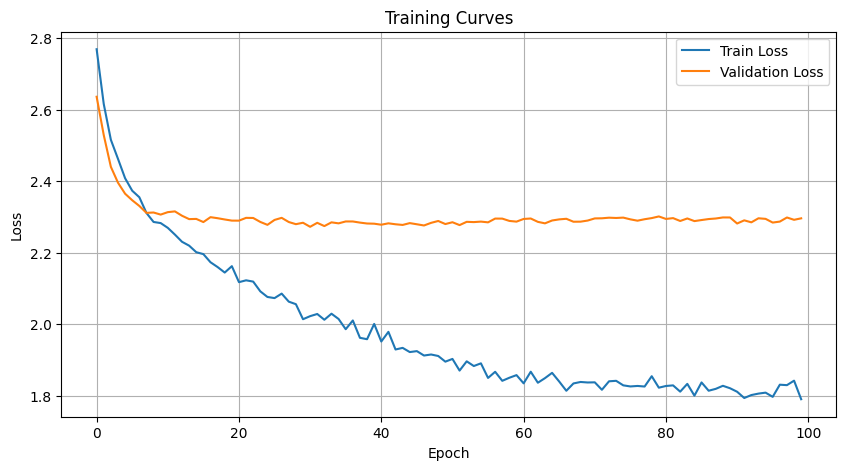

In [37]:
# Cell 11: Train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=10, factor=0.5, min_lr=1e-6
)

epochs = 100
train_losses = []
val_losses = []
best_val_loss = float('inf')

print(f"Training on: {device}")
print("="*50)

# Move test data to device once
X_test_t_device = X_test_t.to(device)
y_test_t_device = y_test_t.to(device)

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        logits = model(X_test_t_device)
        val_loss = criterion(logits, y_test_t_device).item()
    val_losses.append(val_loss)

    # Update learning rate
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_DIR / "best_mbti_model.pth")

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print(f"\nTraining complete! Best validation loss: {best_val_loss:.4f}")

# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves')
plt.legend()
plt.grid(True)
plt.show()


TEST ACCURACY: 0.2905 (29.05%)

=== Classification Report ===
              precision    recall  f1-score   support

        ENFJ       0.30      0.20      0.24        91
        ENFP       0.29      0.25      0.27        91
        ENTJ       0.42      0.40      0.41        91
        ENTP       0.42      0.36      0.39        91
        ESFJ       0.12      0.15      0.14        34
        ESFP       0.27      0.36      0.31        69
        ESTJ       0.16      0.35      0.22        37
        ESTP       0.31      0.29      0.30        92
        INFJ       0.35      0.31      0.33        91
        INFP       0.29      0.17      0.21        89
        INTJ       0.30      0.35      0.32        92
        INTP       0.34      0.44      0.39        90
        ISFJ       0.20      0.44      0.27        66
        ISFP       0.38      0.23      0.28        88
        ISTJ       0.15      0.12      0.13        58
        ISTP       0.28      0.17      0.21        90

    accuracy     

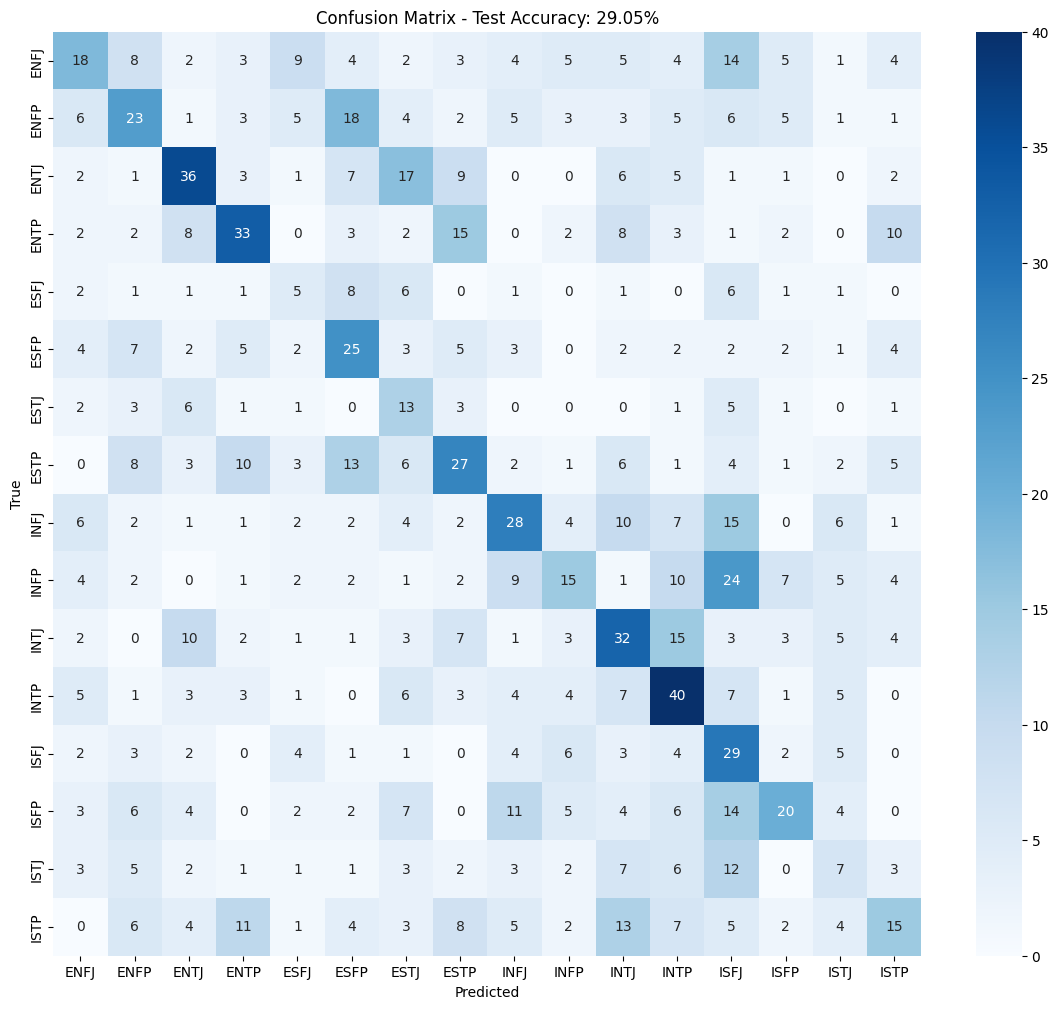

In [38]:
# Cell 12: Evaluate model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load best model
model.load_state_dict(torch.load(MODEL_DIR / "best_mbti_model.pth"))
model.eval()

with torch.no_grad():
    logits = model(X_test_t_device)
    preds = torch.argmax(logits, dim=1).cpu().numpy()

# Calculate accuracy
test_acc = accuracy_score(y_test_t.numpy(), preds)
print(f"\n{'='*50}")
print(f"TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"{'='*50}\n")

# Classification report
print("=== Classification Report ===")
print(classification_report(
    y_test_t.numpy(),
    preds,
    target_names=unique_types
))

# Confusion matrix
plt.figure(figsize=(14, 12))
cm = confusion_matrix(y_test_t.numpy(), preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_types, yticklabels=unique_types)
plt.title(f'Confusion Matrix - Test Accuracy: {test_acc:.2%}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [39]:
# Cell 13: Per-class accuracy
print("\n=== Per-Class Accuracy ===")
per_class_acc = []
for i, mbti_type in enumerate(unique_types):
    true_mask = (y_test_t.numpy() == i)
    if true_mask.sum() > 0:
        class_acc = (preds[true_mask] == i).mean()
        per_class_acc.append(class_acc)
        print(f"{mbti_type:6}: {class_acc:.2%} ({true_mask.sum():3d} samples)")

# Show improvement for minority classes
print(f"\n{'='*50}")
print("Improvement for originally minority classes:")
minority_classes = ['ESFJ', 'ESTJ', 'ISFJ', 'ISTJ']
for mbti_type in minority_classes:
    if mbti_type in unique_types:
        idx = np.where(unique_types == mbti_type)[0][0]
        true_mask = (y_test_t.numpy() == idx)
        if true_mask.sum() > 0:
            class_acc = (preds[true_mask] == idx).mean()
            print(f"  {mbti_type}: {class_acc:.2%}")


=== Per-Class Accuracy ===
ENFJ  : 19.78% ( 91 samples)
ENFP  : 25.27% ( 91 samples)
ENTJ  : 39.56% ( 91 samples)
ENTP  : 36.26% ( 91 samples)
ESFJ  : 14.71% ( 34 samples)
ESFP  : 36.23% ( 69 samples)
ESTJ  : 35.14% ( 37 samples)
ESTP  : 29.35% ( 92 samples)
INFJ  : 30.77% ( 91 samples)
INFP  : 16.85% ( 89 samples)
INTJ  : 34.78% ( 92 samples)
INTP  : 44.44% ( 90 samples)
ISFJ  : 43.94% ( 66 samples)
ISFP  : 22.73% ( 88 samples)
ISTJ  : 12.07% ( 58 samples)
ISTP  : 16.67% ( 90 samples)

Improvement for originally minority classes:
  ESFJ: 14.71%
  ESTJ: 35.14%
  ISFJ: 43.94%
  ISTJ: 12.07%


In [40]:
# Cell 14: Save everything needed for the app
import json

# Save model in format for app
model_path = MODEL_DIR / "mbti_classifier.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim': X_train_scaled.shape[1],
    'num_classes': len(unique_types),
    'classes': unique_types.tolist()
}, model_path)

print(f"Model saved to: {model_path}")

# Save feature list
feature_list = {
    'features': existing_features,
    'n_features': len(existing_features),
    'scaler_path': str(PROCESSED_DIR / "mbti_scaler.pkl")
}

with open(MODEL_DIR / "mbti_features.json", 'w') as f:
    json.dump(feature_list, f, indent=2)

print(f"Features saved to: {MODEL_DIR / 'mbti_features.json'}")

# Save balanced dataset
balanced_df = pd.DataFrame(X_train_balanced, columns=existing_features)
balanced_df['mbti'] = y_train_balanced
balanced_df.to_csv(PROCESSED_DIR / "mbti_balanced.csv", index=False)
print(f"Balanced dataset saved to: {PROCESSED_DIR / 'mbti_balanced.csv'}")

print("\n" + "="*50)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*50)

Model saved to: /content/drive/MyDrive/mbti-tune/models/mbti_classifier.pth
Features saved to: /content/drive/MyDrive/mbti-tune/models/mbti_features.json
Balanced dataset saved to: /content/drive/MyDrive/mbti-tune/data/processed/mbti_balanced.csv

ALL FILES SAVED SUCCESSFULLY!
